# **The Win Condition: Exploring the Impact of Magic: The Gathering Card Features on Deck Win Rates**

**Abby Ortego**

**Milestone 1**

**[Github Webpage](https://abbyortego.github.io/cmps-6790-final-tutorial/)**

In [6]:
import requests
from bs4 import BeautifulSoup
import regex as re
import pandas as pd
import numpy as np
import json
import os

## Project Goal & Plan

[Magic: The Gathering (MTG)](https://magic.wizards.com/en/intro) is a popular, fantasy-based trading card game with competitive tournaments hosted around the globe. By amassing a vast collection of impressive cards, a player can construct their own custom decks from their collection. During deck construction, players must adhere to a deck size limit while maintaining a balance between the types of interaction and resource cards. This trade-off makes for an interesting analysis into what is most important when constructing a game winning deck. 

This notebook aims to answer the following questions: 
1. Do certain features of a deck correlate with the game outcome? 
2. If so, which features have the biggest impact in determining a winning outcome for a player?  
3. Using those features, can we predict the probability of winning a game from just a deck? 

In Milestone 1, I plan to start tackling these questions by first exploring public Magic: The Gathering tournament data that lists the ranks of players and their decks. In Milestone 2, I plan to enrich the deck dataset curated in Milestone 1 by retrieving comprehensive card data from a reliable API source (e.g., [MTGJSON](https://mtgjson.com/), [Scryfall](https://scryfall.com/docs/api)). In the final notebook, I plan to leverage the enriched dataset to train a model that will accept features of a deck, constructed from the aggregate card data, and output the probability of a deck winning. 

## Dataset

The "winability" of a deck is best observed in tournaments which are held around the world, drawing the attention of a variety of players. When a tournament has ended, the host reports participating players, the decks used, tournament outcomes, and more. 

One site that collects and displays this information is [MTGTop8](https://mtgtop8.com) which sources its data from reliable reporting services (e.g., [Melee](https://melee.gg/), [Magic Events](https://magic.gg/), etc.). However, the site has no public facing API, so it must be scraped. Thankfully, it's [Privacy Policy](https://mtgtop8.com/privacy) and [robots.txt](https://mtgtop8.com/robots.txt) file does not ban web scrapers. 

MTGTop8 offers a lot of data on it's site and not all of it is relevant to predicting deck winability. Due to this, we'll focus on only a subset of tournaments and their features. 
- Standard Tournament Format
    - MTG was released in August 1993 and has tournaments hosted around the globe. This has lead to the evolution of a variety of play formats. We will be exploring decks played in standard formatted tournaments. 
    - The standard format is very popular and constrains deck construction to be only from cards released within the last 2-3 years. 
    - By selecting this format, we can avoid the possibility of more recent decks with new fancy abilities overpowering older decks and some aspects of the experience gap that can exist between players.
- Major Events
    - Even though web scraping is not banned by this site, it's still important to be mindful of the number of queries issued. Due to this, we will only be querying data from tournaments listed as "major events". 
    - They're not as common but have a high turn out which will still produce a reliable and large deck dataset with fewer queries. 
- Within the Last Full Month (January 2026 at the time of submission)
    - Rulings and strategies for MTG evolve over time so selecting tournaments that occurred recently will best reflect which current aspects of a deck are most important for winning.   

In summary, this notebook will be extracting and analyzing Magic: The Gathering tournaments from MTGTop8 that are major events played in the standard format within the last full month (January 2026). 

# ETL of Tournament Data

MTGTop8 organizes it's deck data by tournament, so we'll have to scrape tournament data first then visit each tournament page to collect deck related information. This section details that process. 

## Scraping Tournament Data

### Extracting Tournaments

On this [page](https://mtgtop8.com/format?f=ST&meta=46&a=) under the "Last 20 Events" header, major events played in the standard format within the last two months are listed. Unfortunately, these tournaments are paginated and only listed 20 at a time, so we'll have to query for each of these pages using the `cp=` parameter in the URL. 

In [7]:
# get all tournaments tables
tournaments_tables = []
for page in range(1, 8):    # there are roughly 7 pages worth of data
    r = requests.get(f"https://mtgtop8.com/format?f=ST&meta=46&cp={page}")
    if r.status_code != 200:    # checks status code just in case we run into issues
        print(f"Could not scrape events from page {page}.")
        continue
    #

    soup = BeautifulSoup(r.content)
    tables = soup.find_all("table")     # using soup to grab all tables on the page
    tournaments_tables.append(tables[2])   # the table we're interested in is the third one on the page 
#

for row in tournaments_tables[1].find_all('tr')[:2]:    # displays the html for the first 2 rows of the first table
    print(row.prettify())
#

<tr class="hover_tr">
 <td align="center" width="5%">
  <img height="17" src="/graph/online/paper.png" title="Paper"/>
 </td>
 <td class="S14" width="70%">
  <a href="event?e=82260&amp;f=ST">
   MTG China Open S11 - Regional Championship
  </a>
  @
  <a class="und" href="event?e=82260&amp;f=ST">
   Changsha (China)
  </a>
  <span class="new">
   NEW
  </span>
 </td>
 <td align="center" width="13%">
  <img src="/graph/star.png"/>
  <img src="/graph/star.png"/>
  <img src="/graph/star.png"/>
 </td>
 <td align="right" class="S12" width="12%">
  14/03/26
 </td>
</tr>

<tr class="hover_tr">
 <td align="center" width="5%">
  <img height="17" src="/graph/online/paper.png" title="Paper"/>
 </td>
 <td class="S14" width="70%">
  <a href="event?e=81988&amp;f=ST">
   Team Trios Showdown
  </a>
  @
  <a class="und" href="event?e=81988&amp;f=ST">
   NRG Games (Elmhurst, IL)
  </a>
 </td>
 <td align="center" width="13%">
  <img src="/graph/star.png"/>
  <img src="/graph/star.png"/>
  <img src="/graph

Now that we have the tournament tables, we can extract the information we're interested in from the html. We're looking for...
1. **Tournament Names** (to identify tournaments) and **Dates** (to grab recent tournaments)
    - These are stored as text within the html tags, so we can use BeautifulSoup's `get_text()` method to extract this information from the table. 
    - When you do, you get a string that looks like this: `'\n\n\nRCQ @ Draco Hobby Center (Bogota, Colombia)\n\n01/02/26\n\n\n\nMTGO RC Super Qualifier\n\n01/02/26\n\n\n\n2nd Chance PTQ @ Pro Tour Lorwyn Eclipsed (Richmond, VA)\n\n31/01/26\n\n\n\n`
    - It's not very pretty but the new line characters do have a pattern! 3-4 new line characters separate tournaments and 2 new line characters separate tournament name from date. We can use regex to parse the string using this pattern. 
2. **Links** to Additional Tournament Information (for grabbing more details later)
    - These are stored in `a` tags with an `href` property
    - Some entries in the table record an additional `a` tag with the `class` property specified in addition to `href`. These tags have duplicate information that we don't need. 
    - We can use BeautifulSoup's `find_all()` method to find all `a` tags that have an `href` property specified but no `class` property.
    - Lastly, we can use the `get()` method to extract the links. 

In [8]:
# lists to store data
names = []
dates = []
links = []

for tournaments_table in tournaments_tables:
    # (1) Tournament Names and Date
    table_text = tournaments_table.get_text()
    matches = re.finditer(r"""
        (?:\n){3,4}(?P<name>.+)         # 3-4 '\n' (non-captured) followed by a tournament name
        (?:\n){2}(?P<date>.+)       # 2 '\n' (non-captured) followed by a date
        """, 
        table_text, 
        re.VERBOSE      # for multiline to support comments!
    )  
    for match in matches:
        names.append(match.group('name'))
        dates.append(match.group('date'))
    #

    # (2) Links to Additional Tournament Information
    table_hrefs = tournaments_table.find_all("a", href=True, class_=False)      # find all 'a' tags with an 'href' but no 'class'
    links.extend([table_href.get("href") for table_href in table_hrefs])        # get the link
#

display(names[:5], dates[:5], links[:5])

['MTGO Last Chance NEW',
 'MTGO Challenge 64 NEW',
 'MTGO Last Chance NEW',
 'MTGO Last Chance NEW',
 'MTGO Challenge 32 NEW']

['24/03/26', '23/03/26', '23/03/26', '23/03/26', '22/03/26']

['event?e=82359&f=ST',
 'event?e=82372&f=ST',
 'event?e=82307&f=ST',
 'event?e=82272&f=ST',
 'event?e=82306&f=ST']

Finally, we can store this information into a pandas dataframe!

In [9]:
all_tournaments_df = pd.DataFrame({'Name': names, 'Date': dates, 'Link': links})
display(all_tournaments_df.head(), all_tournaments_df.dtypes)

,Name,Date,Link
0,MTGO Last Chance NEW,24/03/26,event?e=82359&f=ST
1,MTGO Challenge 64 NEW,23/03/26,event?e=82372&f=ST
2,MTGO Last Chance NEW,23/03/26,event?e=82307&f=ST
3,MTGO Last Chance NEW,23/03/26,event?e=82272&f=ST
4,MTGO Challenge 32 NEW,22/03/26,event?e=82306&f=ST


Name    str
Date    str
Link    str
dtype: object

### Transforming Tournaments Table

The dataframe we got in the [Extracting](#extracting-tournaments) section above is very close to what we're interested in retrieving as detailed in the [Dataset](#dataset) section, but a few adjustments are still required.

1. No online tournaments

Some of these tournaments include MTG games played online in the app which has a similar but alternative system for collecting cards and creating decks. Due to this we want to only look at tournaments played in person. Thankfully, these online tournaments are denoted with "MTGO" so we can filter the `Name` property of the `tournaments_df` to only include tournaments without "MTGO" in the name. 

In [10]:
# boolean mask of tournament names that do not include MTGO
not_online = ~all_tournaments_df["Name"].str.contains("MTGO")       
all_tournaments_df = all_tournaments_df[not_online].reset_index(drop=True)
display(all_tournaments_df.head())      # only in person tournaments!

,Name,Date,Link
0,"RCQ @ Victory Comics (Falls Church, VA) NEW",21/03/26,event?e=82346&f=ST
1,"RCQ + 1K @ Mont CardShop (Campinas, Brazil) NEW",21/03/26,event?e=82342&f=ST
2,"1k RCQ @ Through the Decades (Louisville, KY) NEW",21/03/26,event?e=82214&f=ST
3,The 33rd God of Standard Tournament @ TC (Toky...,19/03/26,event?e=82205&f=ST
4,Thailand Open - MTG SEA Championships - Oracle...,15/03/26,event?e=82012&f=ST


2. Recent Tournaments

This dataframe contains tournaments from the last **2** months, we are only concerned with tournaments that occurred in the last full month (February 2026). We'll filter out tournaments from before or after that time and convert our `Date` column in the pandas dataframe to the proper type (datetime) to do this.

In [11]:
all_tournaments_df["Date"] = pd.to_datetime(all_tournaments_df["Date"], format="%d/%m/%y")      # format to datetime
# boolean mask of rows between the start & end of January
in_february = (all_tournaments_df["Date"] >= '2026-02-01') & (all_tournaments_df["Date"] < '2026-03-01')         
all_tournaments_df = all_tournaments_df[in_february].reset_index(drop=True)
display(all_tournaments_df.head())      # only in January!

,Name,Date,Link
0,Champions Cup Store Qualifier @ Machida (Japan),2026-02-23,event?e=81001&f=ST
1,Sunday ReCQ #2 @ SCG CON Milwaukee,2026-02-22,event?e=80950&f=ST
2,Sunday RCQ #1 @ SCG CON Milwaukee,2026-02-22,event?e=80949&f=ST
3,Saturday RCQ #2 @ SCG CON Milwaukee,2026-02-21,event?e=80908&f=ST
4,Saturday RCQ #1 @ SCG CON Milwaukee,2026-02-21,event?e=80907&f=ST


3. Base URL for the Link

The `Link` we extracted contains only the suffix of the URL. We need to append the base URL ("https://mtgtop8.com") to this column for easy access later.

In [12]:
base_url = "https://mtgtop8.com"
# concatenate the base URL string with a '/' then the suffix
all_tournaments_df["Link"] = base_url + '/' + all_tournaments_df["Link"]
display(all_tournaments_df.head())      # proper links!

,Name,Date,Link
0,Champions Cup Store Qualifier @ Machida (Japan),2026-02-23,https://mtgtop8.com/event?e=81001&f=ST
1,Sunday ReCQ #2 @ SCG CON Milwaukee,2026-02-22,https://mtgtop8.com/event?e=80950&f=ST
2,Sunday RCQ #1 @ SCG CON Milwaukee,2026-02-22,https://mtgtop8.com/event?e=80949&f=ST
3,Saturday RCQ #2 @ SCG CON Milwaukee,2026-02-21,https://mtgtop8.com/event?e=80908&f=ST
4,Saturday RCQ #1 @ SCG CON Milwaukee,2026-02-21,https://mtgtop8.com/event?e=80907&f=ST


4. Overloaded Name Column

As seen below, the tournament name is storing a lot of information (e.g., day, actual name, and convention). We can use regex to separate the values into their own columns.

In [13]:
all_tournaments_df["Name"][:10]

0      Champions Cup Store Qualifier @ Machida (Japan)
1                   Sunday ReCQ #2 @ SCG CON Milwaukee
2                    Sunday RCQ #1 @ SCG CON Milwaukee
3                  Saturday RCQ #2 @ SCG CON Milwaukee
4                  Saturday RCQ #1 @ SCG CON Milwaukee
5          Mont RCQ @ Mont CardShop (Campinas, Brazil)
6    Regional Championship @ F2FTour.com (Vancouver...
7            Regional Championship @ SCG CON Milwaukee
8         Arena Championship 11 @ Wizards of the Coast
9                   Friday LCQ #16 @ SCG CON Milwaukee
Name: Name, dtype: str

In [14]:
unloaded_name_col = all_tournaments_df['Name'].str.extract(r"""
    (?:Monday\s|Tuesday\s|Wednesday\s|Thursday\s|Friday\s|Saturday\s|Sunday\s)?         # non-capture the day >>> we have the date
    (?P<Name>[^@]+)         # capture everything up until the @ symbol >>> Actual Name
    (?:@)?      # non-capture the @ symbol, if it exists (indicated with ?) >>> Just a delimiter
    (?P<Convention>.+)?         # capture convention, if it exists (indicated with ?) >>> Convention / Location
    """,
    re.VERBOSE
)
display(unloaded_name_col[:10])

,Name,Convention
0,Champions Cup Store Qualifier,Machida (Japan)
1,ReCQ #2,SCG CON Milwaukee
2,RCQ #1,SCG CON Milwaukee
3,RCQ #2,SCG CON Milwaukee
4,RCQ #1,SCG CON Milwaukee
5,Mont RCQ,"Mont CardShop (Campinas, Brazil)"
6,Regional Championship,"F2FTour.com (Vancouver, Canada)"
7,Regional Championship,SCG CON Milwaukee
8,Arena Championship 11,Wizards of the Coast
9,LCQ #16,SCG CON Milwaukee


In [15]:
# inner join the two dataframes on their index columns
all_tournaments_df = all_tournaments_df.merge(unloaded_name_col, right_index=True, left_index=True)
display(all_tournaments_df[:10])

,Name_x,Date,Link,Name_y,Convention
0,Champions Cup Store Qualifier @ Machida (Japan),2026-02-23,https://mtgtop8.com/event?e=81001&f=ST,Champions Cup Store Qualifier,Machida (Japan)
1,Sunday ReCQ #2 @ SCG CON Milwaukee,2026-02-22,https://mtgtop8.com/event?e=80950&f=ST,ReCQ #2,SCG CON Milwaukee
2,Sunday RCQ #1 @ SCG CON Milwaukee,2026-02-22,https://mtgtop8.com/event?e=80949&f=ST,RCQ #1,SCG CON Milwaukee
3,Saturday RCQ #2 @ SCG CON Milwaukee,2026-02-21,https://mtgtop8.com/event?e=80908&f=ST,RCQ #2,SCG CON Milwaukee
4,Saturday RCQ #1 @ SCG CON Milwaukee,2026-02-21,https://mtgtop8.com/event?e=80907&f=ST,RCQ #1,SCG CON Milwaukee
5,"Mont RCQ @ Mont CardShop (Campinas, Brazil)",2026-02-21,https://mtgtop8.com/event?e=80862&f=ST,Mont RCQ,"Mont CardShop (Campinas, Brazil)"
6,Regional Championship @ F2FTour.com (Vancouver...,2026-02-21,https://mtgtop8.com/event?e=80828&f=ST,Regional Championship,"F2FTour.com (Vancouver, Canada)"
7,Regional Championship @ SCG CON Milwaukee,2026-02-21,https://mtgtop8.com/event?e=80827&f=ST,Regional Championship,SCG CON Milwaukee
8,Arena Championship 11 @ Wizards of the Coast,2026-02-21,https://mtgtop8.com/event?e=80826&f=ST,Arena Championship 11,Wizards of the Coast
9,Friday LCQ #16 @ SCG CON Milwaukee,2026-02-20,https://mtgtop8.com/event?e=80808&f=ST,LCQ #16,SCG CON Milwaukee


Since both dataframes had a `Name` column, the merge produces `Name_x`, our old overloaded column, and `Name_y`, our new unloaded column. We no longer need `Name_x` so we can drop it and rename `Name_y` to just `Name`.

In [16]:
all_tournaments_df.drop('Name_x', axis=1, inplace=True)
all_tournaments_df.rename(columns={"Name_y": "Name"}, inplace=True)
display(all_tournaments_df[:10])

,Date,Link,Name,Convention
0,2026-02-23,https://mtgtop8.com/event?e=81001&f=ST,Champions Cup Store Qualifier,Machida (Japan)
1,2026-02-22,https://mtgtop8.com/event?e=80950&f=ST,ReCQ #2,SCG CON Milwaukee
2,2026-02-22,https://mtgtop8.com/event?e=80949&f=ST,RCQ #1,SCG CON Milwaukee
3,2026-02-21,https://mtgtop8.com/event?e=80908&f=ST,RCQ #2,SCG CON Milwaukee
4,2026-02-21,https://mtgtop8.com/event?e=80907&f=ST,RCQ #1,SCG CON Milwaukee
5,2026-02-21,https://mtgtop8.com/event?e=80862&f=ST,Mont RCQ,"Mont CardShop (Campinas, Brazil)"
6,2026-02-21,https://mtgtop8.com/event?e=80828&f=ST,Regional Championship,"F2FTour.com (Vancouver, Canada)"
7,2026-02-21,https://mtgtop8.com/event?e=80827&f=ST,Regional Championship,SCG CON Milwaukee
8,2026-02-21,https://mtgtop8.com/event?e=80826&f=ST,Arena Championship 11,Wizards of the Coast
9,2026-02-20,https://mtgtop8.com/event?e=80808&f=ST,LCQ #16,SCG CON Milwaukee


5. Datatypes

The last thing left to check is the data types for each of these columns and ensure they're right. 

In [17]:
display(all_tournaments_df.dtypes)

Date          datetime64[us]
Link                     str
Name                     str
Convention               str
dtype: object

They are! We're left with the final tournament data frame below.

In [18]:
display(all_tournaments_df.head(), all_tournaments_df.dtypes)

,Date,Link,Name,Convention
0,2026-02-23,https://mtgtop8.com/event?e=81001&f=ST,Champions Cup Store Qualifier,Machida (Japan)
1,2026-02-22,https://mtgtop8.com/event?e=80950&f=ST,ReCQ #2,SCG CON Milwaukee
2,2026-02-22,https://mtgtop8.com/event?e=80949&f=ST,RCQ #1,SCG CON Milwaukee
3,2026-02-21,https://mtgtop8.com/event?e=80908&f=ST,RCQ #2,SCG CON Milwaukee
4,2026-02-21,https://mtgtop8.com/event?e=80907&f=ST,RCQ #1,SCG CON Milwaukee


Date          datetime64[us]
Link                     str
Name                     str
Convention               str
dtype: object

## Scraping Deck Data

### Extracting Decks

The `Link` column in the tournament table leads to a [tournament page](https://mtgtop8.com/event?e=79854&f=ST) with player and deck information listed in the order of their rank. We'll be focusing on extracting this data! Using the `Links` column in the dataframe we created above, we'll grab the html from each tournament page. With this html we'll extract the rank and deck for each player in each tournament.

In [19]:
tournaments_html = []

# get all tournament pages
for idx, row in all_tournaments_df.iterrows():
    r = requests.get(f"{row['Link']}")
    if r.status_code != 200:        # checks status code just in case we run into issues
        print(f"Could not scrape {row['Name']} details from {row['Link']}.")
        continue
    #

    soup = BeautifulSoup(r.content)         # using soup to grab the html
    tournaments_html.append(soup)
#

print(str(tournaments_html[0].prettify())[:500])    # first 500 chars of first tournament_html

<!DOCTYPE HTML>
<html lang="en">
 <head>
  <title>
   Standard event - Champions Cup Store Qualifier @ Machida (Japan) @ mtgtop8.com
  </title>
  <link href="https://www.mtgtop8.com/graph/favicon.png" rel="icon" type="image/png"/>
  <link href="/styles.css" rel="stylesheet" type="text/css"/>
  <script src="https://cache.consentframework.com/js/pa/39346/c/PMQm4/stub" type="text/javascript">
  </script>
  <script async="" src="https://choices.consentframework.com/js/pa/39346/c/PMQm4/cmp" type="tex


When handling the tournament HTML, we'll be looking for the following information...

1. **Players & Rank** are determined based on the order players are extracted in. 
    - MTG Top 8 list players in the left hand panel in order of rank, so we just need to scrape this list. 
    - Unfortunately, players aren't wrapped in a convenient table like tournaments were, but they are wrapped in an `a` tag with the `class` name: "player". 
    - Also, for [really large tournaments](https://mtgtop8.com/event?e=79746&f=ST) the side panel is divided into "Top 8" and "Best Decks" categories where the pattern above is duplicated in both. We only want to extract `a` tags with `class` "player" in the "Top 8" list. Thankfully, a `div` with an `id`, "top8_list" wraps this panel *if it exists*. Using BeautifulSoup's `find()` method, we can try to get the "top8_list" `div` *if it exists*. 

2. **Deck Names & Links** do not have any unique identifiers within the html besides their links. 
    - Deck names are wrapped in an `a` tag with a `href` property similar to this: `<a href="?e=79854&d=806938&f=ST"> Name </a>`.
    - All deck names and links to additional information about them are specified with an event id (the `e=`), deck id (the `d=`), and the Standard play format(`f="ST"`). 
    - We can use regex and BeautifulSoup to find all `a` tags with `href` that follow this observed pattern. Then extract the link and the text!

3. **Deck Prices** can be extracted using the links grabbed in **(2)**. 
    - Each link leads to deck information, such as the list of cards included in the deck and the deck's cumulative market value. 
    - On these pages the deck price is wrapped in a `div` with the `class` "S14 Nav_buy_price". 
    - We can grab the deck prices from each of these links using BeautifulSoup's `find` method to get the first `div` with that class name. 

Once we have this information for each tournament HTML, we can combine into one dataframe that contains deck information for each deck played in all tournaments in the last full month (January 2026). The current index of the for loop indicates which row in the `all_tournaments_df` data is being grabbed for. This can be used to link the two tables later. Data we've collected for other columns can be added as well in tournament sized batches. 

In [20]:
# as we extract data for each tournament we can add it to the decks_df in chunks
decks_df = pd.DataFrame(columns=["Rank", "Player", "Name", "Price", "Link", "TournamentIdx"])

for idx, tournament_html in enumerate(tournaments_html):
    # (1) Players & Rank
    top8_list = tournament_html.find("div", id="top8_list")
    if top8_list:       # if sidebar is split into top 8 list and deck list, only grab "a" tags with "player" class from top 8 list     
        players = [player.get_text() for player in top8_list.find_all("a", class_="player")]
    else:       # otherwise, can just grab directly from the html
        players = [player.get_text() for player in tournament_html.find_all("a", class_="player")]
    #
    ranks = np.arange(1, len(players)+1)        # there are as many ranks as collected players, in order


    # (2) Deck Names & Links
    decks_href = tournament_html.find_all("a", 
        href=re.compile(r"\?e=\d+&d=\d+&f=ST\Z"), 
        string=True
    )[1:]       # the first match is an arrow, but the rest are decks
    deck_names = [deck_href.get_text() for deck_href in decks_href]         # the text is the deck name
    base_url = "https://mtgtop8.com/event"
    deck_links = [base_url + deck_href.get('href') for deck_href in decks_href]

    # (3) Deck Prices
    deck_prices = []
    for deck_link in deck_links:
        r = requests.get(f"{deck_link}")
        if r.status_code != 200:        # checks status code just in case we run into issues
            print(f"Could not scrape deck data for {deck_link}")
            continue
        #

        soup = BeautifulSoup(r.content)
        deck_price_div = soup.find("div", class_="S14 Nav_buy_price").get_text()    # finds first div with this class name
        deck_prices.append(re.findall(r"\d+", deck_price_div)[0])      # extracts just the dollar amount and tracks it
    #

    # (4) Create dataframe for current data and add it to overall dataframe
    tournament_idx = np.full(len(players), idx)   # creates an array of size (players) filled with the current index
    tournament_decks_df = pd.DataFrame({    # current tournament's deck df
        "Rank": ranks, 
        "Player": players, 
        "Name": deck_names, 
        "Price": deck_prices, 
        "Link": deck_links,
        "TournamentIdx": tournament_idx
    })

    decks_df = pd.concat([decks_df, tournament_decks_df], ignore_index=True)        # add to the dataframe with all decks
#

display(decks_df.head())

ConnectTimeout: HTTPSConnectionPool(host='mtgtop8.com', port=443): Max retries exceeded with url: /event?e=80828&d=814438&f=ST (Caused by ConnectTimeoutError(<HTTPSConnection(host='mtgtop8.com', port=443) at 0x114385810>, 'Connection to mtgtop8.com timed out. (connect timeout=None)'))

### Transforming Decks

The dataframe we got in the [Extracting](#extracting-decks) section above still needs a little polishing with the data types!
- Rank is ordinal data so it can stay an `object` 
- Player, Name, and Link are all `strings`
- Price is a `float`
- TournamentIdx is an `integer`

In [ ]:
decks_df[["Player", "Name", "Link"]] = decks_df[["Player", "Name", "Link"]].astype("str")
decks_df["Price"] = decks_df["Price"].astype("float")
decks_df["TournamentIdx"] = decks_df["TournamentIdx"].astype("int")

display(decks_df.head(), decks_df.dtypes)

,Rank,Player,Name,Price,Link,TournamentIdx
0,1,Kageyama Hiroki,Red Deck Wins,97.0,https://mtgtop8.com/event?e=81001&d=815761&f=ST,0
1,2,Yoshiharu Shinozawa,Simic Aggro,1084.0,https://mtgtop8.com/event?e=81001&d=815762&f=ST,0
2,3,Tsuyuki Kouichi,Izzet Prowess,481.0,https://mtgtop8.com/event?e=81001&d=815764&f=ST,0
3,4,Kiyota Takeshi,Simic Nature's Rhythm,1092.0,https://mtgtop8.com/event?e=81001&d=815763&f=ST,0
4,5,Oka Yosuke,Dimir Aggro,464.0,https://mtgtop8.com/event?e=81001&d=815767&f=ST,0


Rank              object
Player               str
Name                 str
Price            float64
Link                 str
TournamentIdx      int64
dtype: object

## Scraping Card Data & Integrating New Features

The previous section detailed the process of extracting [Deck Data](#scraping-deck-data). To better understand the features of a deck, we need to know which cards comprise it. Thankfully, the deck dataframe that was constructed contains links to a list of each decks' cards!

### Extracting Card Data

We can visit each link in the deck dataframe and scrape it's list of card names along with how many copies of that card are in the deck. With this information we can create:
- A cards dataframe with a unique list of each card used in all the tournaments
- A deck cards dataframe that links the cards dataframe with the decks dataframe
    - This is a linking table. A deck can have many cards and a card can belong to many decks which is a "many-to-many" relationship and requires a linking table to adequately represent their relationship. 

When scraping cards, their names and their counts are wrapped in a `div` with a convenient pattern to the classnames. 
- In competitve MTG tournaments, players are allowed a main deck, classnames start with "md", and a side board, classnames start with "sb", to supplement their main deck if they feel the need to swap cards out.
- We can use Beautiful Soup's `find_all` and the regex special character `^` to indicate that we want all `div` with classnames that start with either "md" or "sb". 

Once we have these `div`, we'll need to extract out the count and the name which are separated by a single space once `.get_text()` is applied to the `div`. We can:
- Capture the 1-2 digits that appear first for the count (`\d{1,2}`)
- Track but not capture the single space (`\s`)
- Capture the rest of the string (`.+`) which is the card name

We can construct a card dataframe by only adding new cards if their name doesn't appear already in the dataframe. The linking table is constructed by combining the current deck index, card index, and card count into one dataframe. 

In [ ]:
# as we extract decks from the tournament, we can add them to a cards_df
cards_df = pd.DataFrame(columns=["Name"])

# need to be able to link cards to their decks, as well
deck_cards_df = pd.DataFrame(columns=["DeckIdx", "CardIdx", "Count"]) 

for idx, row in decks_df.iterrows():
    r = requests.get(f"{row['Link']}")
    if r.status_code != 200:        # checks status code just in case we run into issues
        print(f"Could not scrape card data for {row["Name"]} deck with ID {idx}")
        continue
    #

    soup = BeautifulSoup(r.content)
    card_divs = soup.find_all("div", id=re.compile(r"^md|^sb"))     # finding all main deck or side board cards

    for div in card_divs:
        count, card = re.split(r"(\d{1,2})(?:\s)(.+)", div.get_text())[1:3]     # extracting card count and name
        if card.strip() not in cards_df["Name"].values:
            cards_df.at[len(cards_df), "Name"] = card.strip()   # accessing specific value
        #

        card_df_idx = cards_df.index[cards_df["Name"] == card.strip()].to_list()[0]
        deck_cards_df.loc[len(deck_cards_df), :] = [idx, card_df_idx, count]
    #
#

display(cards_df.head(), deck_cards_df.head())

,Name
0,Mountain
1,Rockface Village
2,Burnout Bashtronaut
3,Greasewrench Goblin
4,Hired Claw


,DeckIdx,CardIdx,Count
0,0,0,20
1,0,1,2
2,0,2,4
3,0,3,4
4,0,4,4


### Extracting Additional Card Features

The card dataframe extracted above only contains the name of a card. As mentioned in the [Datasets](#dataset) section, we'll need more than that to get a better understanding of the defining features of a deck. Thankfully, [MTGJSON](https://mtgjson.com) has datasets with a variety of interesting card features. 

In order to make the competition fair, MTG limits the sets that can be used to construct decks in standard tournaments to those released roughly within the last year (see more [here](https://magic.wizards.com/en/formats/standard)). The current valid sets:
- Teenage Mutant Ninja Turtles (TMT)
- Lorwyn Eclipsed (ECL)
- Avatar: The Last Airbender (TLA)
- Marvel’s Spider-Man (SPM)
- Edge of Eternities (EOE)
- FINAL FANTASY (FIN)
- Tarkir: Dragonstorm (TDM)
- Aetherdrift (DFT)
- Foundations (FDN)
- Duskmourn: House of Horror (DSK)
- Bloomburrow (BLB)
- Outlaws of Thunder Junction (OTJ)
- Murders at Karlov Manor (MKM)
- The Lost Caverns of Ixalan (LCI)
- Wilds of Eldraine (WOE)

MTGJSON allows us to download each of these sets individually [here](https://mtgjson.com/downloads/all-sets/). The `mtg-sets` directory stores a JSON file for each set. 

We can iterate over each of these JSON files, extract their list of cards and the following card features for each set. These features were chosen since they best communicate the capabilities and cost of each card in a deck. You can read more about features of magic cards [here](https://magic.wizards.com/en/news/feature/anatomy-magic-card-2006-10-21). 
- Every card has a...
    - Name: to help us link with the card dataframe later
    - Type: indicates if the card is a resource card (also known as "mana") or which type of non-resource card it is (e.g., creature, enchantment, artifact, etc)
        - Note: some cards can have more than one type. These combine into a new type using the `.join` operator on lists. 
    - Rarity: how often the card is pulled
    - Mana Value: the type of resource a card requires or is
        - Resource cards *are* mana
        - Non-resource cards *cost* mana
- Creature cards are non-resource cards that deal damage and have...
    - Power: the amount of damage they can deal
    - Toughness: the amount of damage they can take (also known as their "life")
- Any card type has the possibility of being "Legendary" (indicated by the card's "supertype")
    - This typically means that the card has unique and/or powerful abilities. 
- Any non-resource card can have any number of special, extra abilities (indicated by the card's "keywords"). 
    - For this feature, we'll just track the number of keywords as a simple way of estimating the card's uniqueness. 
- Some cards are double sided. For the sake of simplicity, we'll only track features on the front of the card. 

In [ ]:
cards_feat_df = pd.DataFrame(columns=["Name", "Mana", "Type", "Rarity", "Legendary", "Power", "Toughness", "Ability Count"])

for file in os.scandir("mtg-sets/"):
    with open(file.path, "r") as f:
        set_json = json.load(f)
        set_cards_json = set_json["data"]["cards"]

        for card in set_cards_json:
            # ignoring cards that already exist
            if card["name"] in cards_feat_df["Name"].values:
                continue  
            #

            new_card_idx = len(cards_feat_df)

            # get features all cards have
            cards_feat_df.loc[new_card_idx, ["Name", "Type", "Rarity"]] = [
                card["name"],
                ' '.join(card["types"]),
                card["rarity"]
            ]

            # get mana value for cards
            if "Land" in card["types"]:
                formatted_mana = [f"{{{color}}}" for color in card["colorIdentity"]]
                cards_feat_df.at[new_card_idx, "Mana"] = "".join(formatted_mana)
            else:
                cards_feat_df.at[new_card_idx, "Mana"] = card["manaCost"]
            #

            # get features all creatures have
            if "Creature" in card["types"]:
                cards_feat_df.loc[new_card_idx, ["Power", "Toughness"]] = [
                    card["power"],
                    card["toughness"]
                ]
            #

            # track legendary cards
            if "Legendary" in card["supertypes"]:
                cards_feat_df.at[new_card_idx, "Legendary"] = True
            #

            # track the number of special abilities
            if "keywords" in card:
                cards_feat_df.at[new_card_idx, "Ability Count"] = len(card["keywords"])
            #
        #
    #
#

display(cards_feat_df.head())

,Name,Mana,Type,Rarity,Legendary,Power,Toughness,Ability Count
0,Action News Crew,{1}{W},Creature,common,NaN,2,2,2
1,"Agent Bishop, Man in Black",{2}{W},Creature,rare,True,1,2,NaN
2,"April O'Neil, Kunoichi Trainee",{1}{W},Creature,common,True,2,2,1
3,Dimensional Exile,{1}{W},Enchantment,uncommon,NaN,NaN,NaN,1
4,East Wind Avatar,{3}{W},Creature,common,NaN,2,4,3


### Linking Cards & Card Features

Now that we have additional card features from MTGJSON, we can link these card features to the cards we extracted from MTGTop8 by using the "Name" column.

As mentioned in the [Extracting](#extracting-additional-card-features) section above, some cards have two sides. MTGJSON lists these card names as `[name on front] // [name on back]`, but MTGTop8 lists only the name on the front of the card. We'll need to get rid of everything after the "//" in the MTGJSON data before we can merge on name. 

In [ ]:
cards_feat_df["Name"] = cards_feat_df["Name"].str.split(" //", expand=True).iloc[:, 0].str.strip()
display(cards_feat_df["Name"].head())

0                  Action News Crew
1        Agent Bishop, Man in Black
2    April O'Neil, Kunoichi Trainee
3                 Dimensional Exile
4                  East Wind Avatar
Name: Name, dtype: object

We will do a "left" join since we only want to keep features for cards that we scraped and those cards are stored in the dataframe on the left. 

In [ ]:
cards_df = pd.merge(cards_df, cards_feat_df, on="Name", how="left")
display(cards_df.head())

,Name,Mana,Type,Rarity,Legendary,Power,Toughness,Ability Count
0,Mountain,{R},Land,common,NaN,NaN,NaN,NaN
1,Rockface Village,{R},Land,uncommon,NaN,NaN,NaN,NaN
2,Burnout Bashtronaut,{R},Creature,rare,NaN,1,1,3
3,Greasewrench Goblin,{R},Creature,uncommon,NaN,2,1,1
4,Hired Claw,{R},Creature,rare,NaN,1,2,NaN


Now we can check if any cards slipped through the cracks by seeing if any of the columns that all cards should have information more have any `NaN`. 

In [ ]:
missing_cards = cards_df[cards_df[["Mana", "Type", "Rarity"]].isnull().any(axis=1)]
display(missing_cards)

,Name,Mana,Type,Rarity,Legendary,Power,Toughness,Ability Count
139,Roaring Furnace / Steaming Sauna,NaN,NaN,NaN,NaN,NaN,NaN,NaN
312,Unholy Annex / Ritual Chamber,NaN,NaN,NaN,NaN,NaN,NaN,NaN
409,Cease / Desist,NaN,NaN,NaN,NaN,NaN,NaN,NaN
461,Scar,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Looks like we're only missing data for four cards! 

The first three belong to a very special type of card. The card is split into two (as hinted by the "/") and the player gets to choose which one they will play it as. Due to their oddity and the small number of them, we can fill in it's data by hand. For simplicity, we'll choose the cheaper mana option to represent the card's in-game cost and we'll say it has one special ability to account for it's "choose one" option.  

In [ ]:
cards_df.loc[139, ["Mana", "Type", "Rarity", "Ability Count"]] = ["{1}{R}", "Enchantment", "rare", 1]
cards_df.loc[312, ["Mana", "Type", "Rarity", "Ability Count"]] = ["{2}{B}", "Enchantment", "rare", 1]
cards_df.loc[409, ["Mana", "Type", "Rarity", "Ability Count"]] = ["{4}{B}{G}", "Enchantment", "rare", 1]

missing_cards = cards_df[cards_df[["Mana", "Type", "Rarity"]].isnull().any(axis=1)]
display(missing_cards)

,Name,Mana,Type,Rarity,Legendary,Power,Toughness,Ability Count
461,Scar,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The final card is missing completely at random. It cannot be found when looking up online.

### Transforming the Card Data

Now we have features for each card that can legally be played in standard tournaments! There is still some cleaning required though. 

1. Mana

Currently, the mana column is overloaded. There are 6 *kinds* of resource cards, or types of mana, and this column contains all of them in a specific format. Since a card could provide any type of mana or require any type of mana to be played, we will separate out this one column into 6, one for each type.

Mana is abbreviated as "W" for white, "U" for blue, "B" for black, "R" for red, or "G" for green. The frequency of each of these letters tells either (1) how much of that mana type will need to be used if on a non-resource card or (2) how much mana is produced if on a resource card. We can count their frequency by using Regex `.findall()` and then get the length of the list it returns. A special sixth resource type is colorless. The amount is indicated by a single digit or the number of "X". We use Regex to grab the digit or all the "X" if either exists.

In [ ]:
for idx, row in cards_df[~cards_df["Mana"].isna()].iterrows():
    mana = {
        "white": 0,
        "blue": 0,
        "black": 0,
        "red": 0,
        "green": 0,
        "colorless": 0
    }

    # white
    mana["white"] = len(re.findall(r"\{W\}", row["Mana"]))
    
    # blue
    mana["blue"] = len(re.findall(r"\{U\}", row["Mana"]))

    # black
    mana["black"] = len(re.findall(r"\{B\}", row["Mana"]))

    # red
    mana["red"] = len(re.findall(r"\{R\}", row["Mana"]))

    # green
    mana["green"] = len(re.findall(r"\{G\}", row["Mana"]))

    # colorless
    if "X" in row["Mana"]:
        mana["colorless"] += len(re.findall(r"\{X\}", row["Mana"]))
    elif re.search(r"\d", row["Mana"]):
        mana["colorless"] += int(re.findall(r"\d", row["Mana"])[0])
    #

    cards_df.loc[idx, ["White", "Blue", "Black", "Red", "Green", "Colorless"]] = list(mana.values())
#

display(cards_df.head())

,Name,Mana,Type,Rarity,Legendary,Power,Toughness,Ability Count,White,Blue,Black,Red,Green,Colorless
0,Mountain,{R},Land,common,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0
1,Rockface Village,{R},Land,uncommon,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0
2,Burnout Bashtronaut,{R},Creature,rare,NaN,1,1,3,0.0,0.0,0.0,1.0,0.0,0.0
3,Greasewrench Goblin,{R},Creature,uncommon,NaN,2,1,1,0.0,0.0,0.0,1.0,0.0,0.0
4,Hired Claw,{R},Creature,rare,NaN,1,2,NaN,0.0,0.0,0.0,1.0,0.0,0.0


2. Datatypes

Some of our columns do not have the proper datatypes, so we'll need to convert them.
- Name, Type, and Rarity should be `str`
- Columns relaying mana counts, Power, Toughness, and Ability Count should be `int` as these are all whole numbers
- Legendary indicates if a card is legendary or not. Any values, such as `NaN`, that aren't True should be False. 

Lastly, some of our columns (e.g., Mana) are no longer useful so we can drop them!

In [ ]:
cards_df[["Name", "Type", "Rarity"]] = cards_df[["Name", "Type", "Rarity"]].astype("str")
cards_df[["White", "Blue", "Black", "Red", "Green", "Colorless"]] = cards_df[["White", "Blue", "Black", "Red", "Green", "Colorless"]].astype("Int64")
cards_df["Legendary"] = cards_df["Legendary"].fillna(False).astype("bool")

cards_df.drop("Mana", axis=1, inplace=True)

display(cards_df.head(), cards_df.dtypes)

,Name,Type,Rarity,Legendary,Power,Toughness,Ability Count,White,Blue,Black,Red,Green,Colorless
0,Mountain,Land,common,False,NaN,NaN,NaN,0,0,0,1,0,0
1,Rockface Village,Land,uncommon,False,NaN,NaN,NaN,0,0,0,1,0,0
2,Burnout Bashtronaut,Creature,rare,False,1,1,3,0,0,0,1,0,0
3,Greasewrench Goblin,Creature,uncommon,False,2,1,1,0,0,0,1,0,0
4,Hired Claw,Creature,rare,False,1,2,NaN,0,0,0,1,0,0


Name                str
Type                str
Rarity              str
Legendary          bool
Power            object
Toughness        object
Ability Count    object
White             Int64
Blue              Int64
Black             Int64
Red               Int64
Green             Int64
Colorless         Int64
dtype: object

# Exploratory Data Analysis

In [ ]:
all_tournaments_df.to_csv("all_tournaments_df.csv")
decks_df.to_csv("decks_df.csv")
cards_df.to_csv("cards_df.csv")
deck_cards_df.to_csv("deck_cards_df.csv")

In [ ]:
all_tournaments_df = pd.read_csv("all_tournaments_df.csv", index_col=0)
decks_df = pd.read_csv("decks_df.csv", index_col=0)
cards_df = pd.read_csv("cards_df.csv", index_col=0)
deck_cards_df = pd.read_csv("deck_cards_df.csv", index_col=0)

display(all_tournaments_df.head(), decks_df.head(), cards_df.head(), deck_cards_df.head())

,Date,Link,Name,Convention
0,2026-02-23,https://mtgtop8.com/event?e=81001&f=ST,Champions Cup Store Qualifier,Machida (Japan)
1,2026-02-22,https://mtgtop8.com/event?e=80950&f=ST,ReCQ #2,SCG CON Milwaukee
2,2026-02-22,https://mtgtop8.com/event?e=80949&f=ST,RCQ #1,SCG CON Milwaukee
3,2026-02-21,https://mtgtop8.com/event?e=80908&f=ST,RCQ #2,SCG CON Milwaukee
4,2026-02-21,https://mtgtop8.com/event?e=80907&f=ST,RCQ #1,SCG CON Milwaukee


,Rank,Player,Name,Price,Link,TournamentIdx
0,1,Kageyama Hiroki,Red Deck Wins,97.0,https://mtgtop8.com/event?e=81001&d=815761&f=ST,0
1,2,Yoshiharu Shinozawa,Simic Aggro,1084.0,https://mtgtop8.com/event?e=81001&d=815762&f=ST,0
2,3,Tsuyuki Kouichi,Izzet Prowess,481.0,https://mtgtop8.com/event?e=81001&d=815764&f=ST,0
3,4,Kiyota Takeshi,Simic Nature's Rhythm,1092.0,https://mtgtop8.com/event?e=81001&d=815763&f=ST,0
4,5,Oka Yosuke,Dimir Aggro,464.0,https://mtgtop8.com/event?e=81001&d=815767&f=ST,0


,Name,Type,Rarity,Legendary,Power,Toughness,Ability Count,White,Blue,Black,Red,Green,Colorless
0,Mountain,Land,common,False,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0
1,Rockface Village,Land,uncommon,False,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0
2,Burnout Bashtronaut,Creature,rare,False,1,1,3.0,0.0,0.0,0.0,1.0,0.0,0.0
3,Greasewrench Goblin,Creature,uncommon,False,2,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,Hired Claw,Creature,rare,False,1,2,NaN,0.0,0.0,0.0,1.0,0.0,0.0


## Deck Prices

It is a common belief within the community that the more a card (or deck) is valued the more likely a player's chances are for success. While this may hold more truth for MTG when compared to other popular trading card games, many argue that there are other aspects to deck building that are equally as important. 

This section starts to analyze the relationship between a deck's market value and it's tournament success, or rank. 

### What was the average cost of a deck for each rank? 

To answer this question, we can group the decks dataframe by "Rank". Then aggregate by calculating the average price for each group, or rank. To make this output fit traditional standards of communicating money, we'll round it to two decimal places.

In [ ]:
rank_prices = decks_df.groupby("Rank")["Price"].mean().round(2)
display(rank_prices)

Rank
1     575.38
2     705.07
3     594.55
4     603.17
5     588.66
       ...  
60    906.00
61    443.00
62    472.00
63    364.00
64    563.00
Name: Price, Length: 64, dtype: float64

### Most Expensive vs the Cheapest Rank

Next, we can see which ranks have the most expensive and cheapest decks on average. If price does play a huge role in the ranking of a deck, then we'd expect to see the cheapest deck and most expensive deck on opposite ends of one another (i.e., top rank has the most expensive deck on average and bottom rank has cheapest or vice versa).

We can grab the most and least expensive deck by using `.min()` and `.max()` on the rankings.

In [ ]:
print(f"Cheapest Deck Price: {int(rank_prices.min())} \t Cheapest Deck Rank: {int(rank_prices.idxmin())}")
print(f"Expensive Deck Price: {int(rank_prices.max())} \t Expensive Deck Rank: {int(rank_prices.idxmax())}")

Cheapest Deck Price: 320 	 Cheapest Deck Rank: 46
Expensive Deck Price: 1115 	 Expensive Deck Rank: 55


While the rank with cheapest decks on average may not be very high, it is still higher than the rank with the most expensive decks on average! It also looks like average price of the #1 ranked deck is somewhere in the middle of these values, which suggests that deck price may not be the biggest deciding factor for winability. 

## Deck Archetypes

Since prices might not be the *only* factor to consider, we can start by diving deeper into the contents of a deck by investigating "Deck Archetypes". 

When a deck wins many MTG tournaments, it is typically deconstructed into the type of cards it contains and becomes a template for new decks to be built from. The `Name` column in the `decks_df` refers to a deck's archetype, or template, that it is inspired by. Decks with the same archetype will be similar in features, but cards may differ since decks are constructed from a player's existing pool of cards.

If an archetype becomes really popular it usually has something to do with the core features of the cards within the deck (e.g., the mana curve or the variety of card types) being effective components for winning. Due to this, we'll be exploring archetypes within our list of decks for this section. 

### What was the most popular deck archetype?

We can look at the most frequent name in the deck's dataframe by using `.mode()`.

In [ ]:
display(decks_df["Name"].mode())        # archetypes are listed by name, so grab most frequent value in 'Name' column

0    Izzet Lesson
Name: Name, dtype: str

### Which deck archetype was most common for each rank? 

To get the msot frequent archetype by rank, we can group the decks dataframe by "Rank" then aggregate on the "Name" column by finding the most frequent archetype in each group. 

In [ ]:
# groupby "Rank" column then aggregate by most frequent archetype in the "Name" column
display(decks_df.groupby("Rank")["Name"].agg(lambda group: group.mode()[0]))

Rank
1                   Izzet Lesson
2            Mono Green Landfall
3                   Izzet Lesson
4            Mono Green Landfall
5                    Dimir Aggro
                 ...            
60           Superior Reanimator
61    Temur Full Bore Harmonizer
62    Temur Full Bore Harmonizer
63    Temur Full Bore Harmonizer
64                    UW Control
Name: Name, Length: 64, dtype: str

### The most popular archetype matches the most popular deck for the highest rank!

Izzet Lesson is the most popular archetype overall and it happens to be the most common deck in Rank 1. This could be due to one of the following:
- The deck's popularity is due to it's effectiveness. This deck archetype may be very strong and that is why it's able to achieve top rank.
- Or, the deck's effectiveness is due to its popularity. This deck archetype may have easier mechanics which makes it a popular choice in tournaments and therefore increases the chances of it winning.

To determine this properly, we must go beyond just deck archetype and actually dig into card features.

## Mana Curve

scatter plot

In [ ]:
linked_cards_df = pd.merge(cards_df, deck_cards_df, left_index=True, right_on="CardIdx", how="inner")

# groupby deck idx

# sum across mana cols

# groupby card mana total 

# mode of cards in each 

# get mode of that

# record the mana total most cards are concentrated within for the deck

In [ ]:
# plot rank vs mana curve on scatter & interpret

## Ratio of Card Types

Box-plot per card type

In [ ]:
# merge with linking table

# groupby deck idx

# groupby card type

# divide card type group size by deck group size to get ratio & report


In [ ]:
# plot for each card type with distribution

# Modeling

## Rank Distribution

The end goal of this notebook is to train a model to predict deck's winability based off the ranks we've collected, so it's important to visualize the distribution of our dataset over rank. This helps us identify class imbalances and get a general understanding of our dataset!

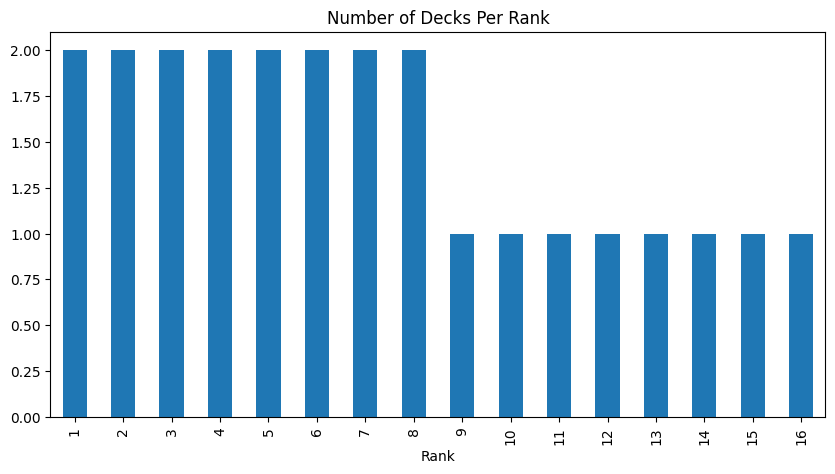

In [ ]:
rank_freq = decks_df["Rank"].value_counts()         # counts frequency of unique values in "Rank"
rank_freq.plot.bar(title="Number of Decks Per Rank", figsize=(10, 5))       # bar plot 
plt.show()

The distribution of decks per rank is right skewed, meaning that there is drastically more deck data for ranks 1-16 than 16-32. This is something I'll have to keep in mind when modeling later!

## RQ 1

Which feature has the biggest impact on a deck's rank in competitive tournaments?

### EDA Motivations


### Variables / Features

Dependent Variables: 
- Deck Rank (as an ordinal variable)

Independent Variables: 
- Mana Curve
- Ratio of Card Types
- Price
- Average Number of Special Abilities
- Ratio of Card Rarity
- Number of Legendary Cards

Which independent variables(s) have the biggest impact on the dependent variable?

### Method

I plan to train a Logistic Regression model to predict the probability of a deck being rank 1-8. The rank with the highest probability will be the predicted rank for that deck. I will test this model by how many decks it accurately reports the correct rank for.

Once trained, I will examine the learned coefficient for each independent variable and extract variables that have the largest coeffecients in magnitude. Thos variables have the biggest impact on determining a deck's rank, or ability to win. 

## RQ 2

Can we predict the price of a deck given it's features? How does ranking of the deck effect the predicted price? 

### EDA Motivations


### Variables / Features

Dependent Variables: 
- Deck Price (as a continuous numerical variable)

Independent Variables: 
- Mana Curve
- Ratio of Card Types
- Average Number of Special Abilities
- Ratio of Card Rarity
- Number of Legendary Cards
- Rank (with and without)

Which independent variables(s) have the biggest impact on the dependent variable?

### Method

I plan to train a Linear Regression model to predict a deck's price given the indepent variables including rank and excluding rank. I will test this model by computing the Mean Squared Error (MSE) between the predicted price and the true pric.

Once both versions are trained, I will compare the MSE between the two versions and see if one version outperformed the other.

# References
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.extract.html
- https://pandas.pydata.org/docs/user_guide/groupby.html#the-aggregate-method 
- https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html

In [ ]:
# !jupyter nbconvert --to html /Users/aortego1/Documents/YR1/S2026/CMPS-6790-DS/FinalNotebook/cmps-6790-final-tutorial/Milestone1_FD.ipynb